
### Práctica 3 - Series de Fourier 

#### Presentado por: Alma Olea Barbosa - Lauren Cordero Ramos 

#### Semestre: 2026-2

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Se definen parámetros necesarios en la construcción de las señales

f0 = 10          # frecuencia fundamental [Hz]
A = 1.0           # amplitud
P = 5             # numero de periodos a generar
fs = 2000.0       # frecuencia de muestreo [Hz]
N_per = int(fs / f0)   # muestras por periodo (200)
N = N_per * P          # numero total de muestras (800)
t = np.arange(N) / fs  # vector de tiempo


a - Construcción de la señal cuadrada periódica 

In [3]:
def senal_cuadrada_periodica(t, f0, A):
    fase = np.round((f0 * t) % 1.0, 9)  # fase normalizada en [0, 1)
    return A * np.where(fase < 0.5, 1.0, -1.0)

b - Construcción de la señal triangular periódica 

In [4]:
def senal_triangular_periodica(t, f0, A):
    return (2 * A / np.pi) * np.arcsin(np.sin(2 * np.pi * f0 * t))

c - Gráfica de la señal cuadrada y triangular (ambas periódicas) en el dominio del tiempo 

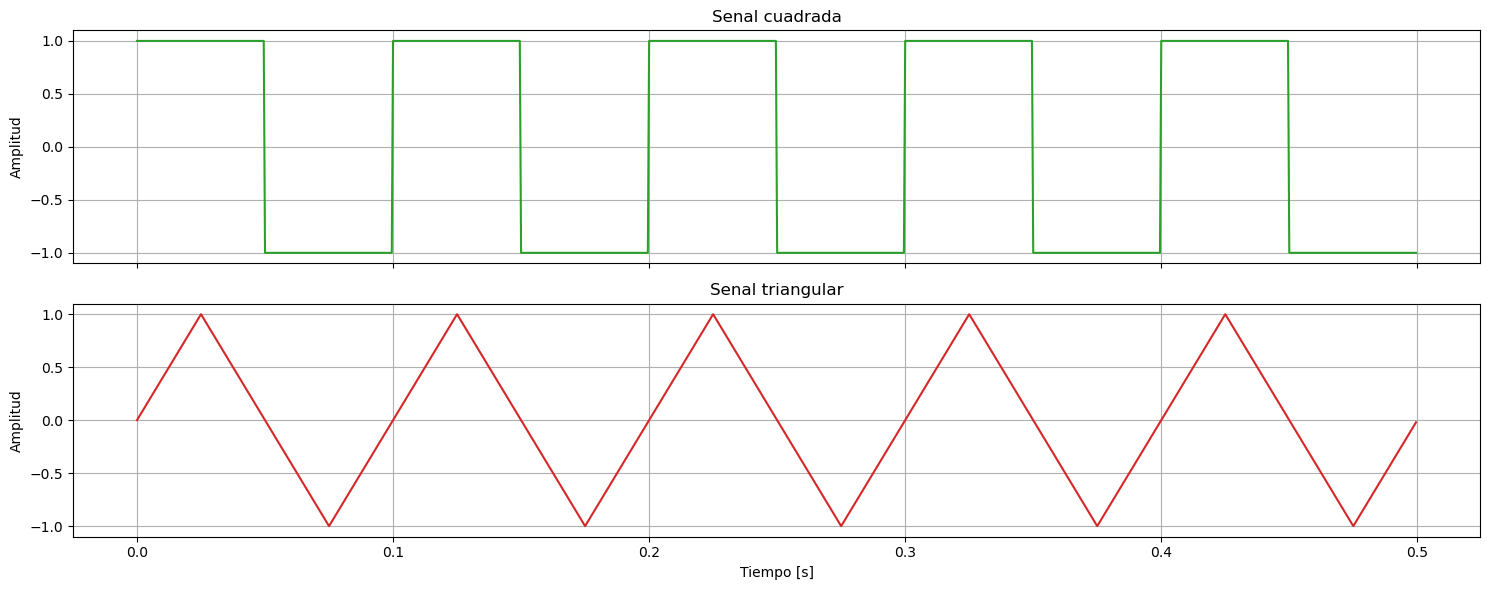

In [8]:
x_cuadrada = senal_cuadrada_periodica(t, f0, A)
x_triangular = senal_triangular_periodica(t, f0, A)

fig, ax = plt.subplots(2, 1, figsize=(15, 6), sharex=True)
ax[0].plot(t, x_cuadrada, color="tab:green")
ax[0].set_title("Senal cuadrada")
ax[1].plot(t, x_triangular, color="tab:red")
ax[1].set_title("Senal triangular")
ax[1].set_xlabel("Tiempo [s]")
for a in ax:
    a.set_ylabel("Amplitud")
    a.grid(True)

plt.tight_layout()

d - Función que recibe la señal periódica y devuelve sus coeficientes de la serie de fourier

In [9]:
#    c_k = (1/T) * integral_0^T x(t) e^{-j k w0 t} dt
#    En discreto (un periodo de N_per muestras): c_k = (1/N_per) * sum x[n] e^{-j 2 pi k n / N_per}
#    que es exactamente FFT(x)/N_per.
def coeficientes_fourier(x, muestras_por_periodo, K=None):
    """Devuelve (k, c_k) para k = -K..K a partir de UN periodo de la senal."""
    xp = np.asarray(x)[:muestras_por_periodo]
    M = len(xp)
    c = np.fft.fft(xp) / M
    k = np.fft.fftfreq(M, d=1.0 / M).astype(int)  # indices armonicos
    k = np.fft.fftshift(k)
    c = np.fft.fftshift(c)
    if K is not None:
        mask = np.abs(k) <= K
        k, c = k[mask], c[mask]
    return k, c


e - Coeficientes de la señal cuadrada y triangular 

Se muestran únicamente los coeficientes cuya magnitud supera 10⁻³. Los coeficientes restantes (k = 0 y k par) son teóricamente nulos debido a la simetría de media onda de ambas señales, y su valor numérico (~10⁻¹⁶) corresponde a error de redondeo. Además, se truncó el análisis a |k| ≤ 15, ya que estos armónicos concentran aproximadamente el 97.5 % de la potencia de la señal cuadrada y más del 99.9 % de la triangular."

In [13]:
K = 15
k_c, c_cuadrada = coeficientes_fourier(x_cuadrada, N_per, K)
k_t, c_triangular = coeficientes_fourier(x_triangular, N_per, K)


def mostrar_coeficientes(k, c, f0, titulo="", tol=1e-3):
    print(f"\nCoeficientes de Fourier - {titulo}")
    print("-" * 74)
    print(f"{'k':>4} {'f [Hz]':>9} {'Re(c_k)':>10} {'Im(c_k)':>10} "
          f"{'|c_k|':>9} {'Fase [rad]':>11} {'Fase [grados]':>14}")
    print("-" * 74)
    for ki, ci in zip(k, c):
        if abs(ci) > tol:
            fase = np.angle(ci)
            print(f"{ki:>4d} {ki * f0:>9.1f} {ci.real:>10.4f} {ci.imag:>10.4f} "
                  f"{abs(ci):>9.4f} {fase:>11.4f} {np.degrees(fase):>14.2f}")
    print("-" * 74)


mostrar_coeficientes(k_c, c_cuad, f0, "senal cuadrada")
mostrar_coeficientes(k_t, c_tri, f0, "senal triangular")


Coeficientes de Fourier - senal cuadrada
--------------------------------------------------------------------------
   k    f [Hz]    Re(c_k)    Im(c_k)     |c_k|  Fase [rad]  Fase [grados]
--------------------------------------------------------------------------
 -15    -150.0     0.0100     0.0417    0.0428      1.3352          76.50
 -13    -130.0     0.0100     0.0483    0.0493      1.3666          78.30
 -11    -110.0     0.0100     0.0573    0.0582      1.3980          80.10
  -9     -90.0     0.0100     0.0703    0.0710      1.4294          81.90
  -7     -70.0     0.0100     0.0906    0.0911      1.4608          83.70
  -5     -50.0     0.0100     0.1271    0.1275      1.4923          85.50
  -3     -30.0     0.0100     0.2120    0.2123      1.5237          87.30
  -1     -10.0     0.0100     0.6366    0.6366      1.5551          89.10
   1      10.0     0.0100    -0.6366    0.6366     -1.5551         -89.10
   3      30.0     0.0100    -0.2120    0.2123     -1.5237         -

f - Función que recibe el conjunto de coeficientes de fourier

In [ ]:
def espectros_fourier(c, f0=1.0, titulo="", tol=1e-8,
                      color_mag="tab:blue", color_fase="tab:red"):
    c = np.asarray(c)
    M = len(c)
    k = np.arange(M) - M // 2   # índices armonicos, que se encuentran centrados en k = 0
    f = k * f0

    mag = np.abs(c)
    fase = np.angle(c)
    fase[mag < tol] = 0.0       # la fase no tiene sentido donde |c_k| es aproximadamente 0

    fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    ax[0].stem(f, mag, linefmt=color_mag, markerfmt="o", basefmt="k-")
    ax[0].set_ylabel("|c_k|")
    ax[0].set_title(f"Espectro de magnitud - {titulo}")

    ax[1].stem(f, fase, linefmt=color_fase, markerfmt="o", basefmt="k-")
    ax[1].set_ylabel("Fase [rad]")
    ax[1].set_xlabel("Frecuencia [Hz]" if f0 != 1.0 else "Armónico k")
    ax[1].set_title(f"Espectro de fase - {titulo}")

    # Eje de fase en múltiplos de pi
    ax[1].set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
    ax[1].set_yticklabels(["-π", "-π/2", "0", "π/2", "π"])
    ax[1].set_ylim(-np.pi * 1.1, np.pi * 1.1)

    for a in ax:
        a.grid(True)
    plt.tight_layout()

g - Espectros de magnitud y fase para la señal cuadrada y triangular

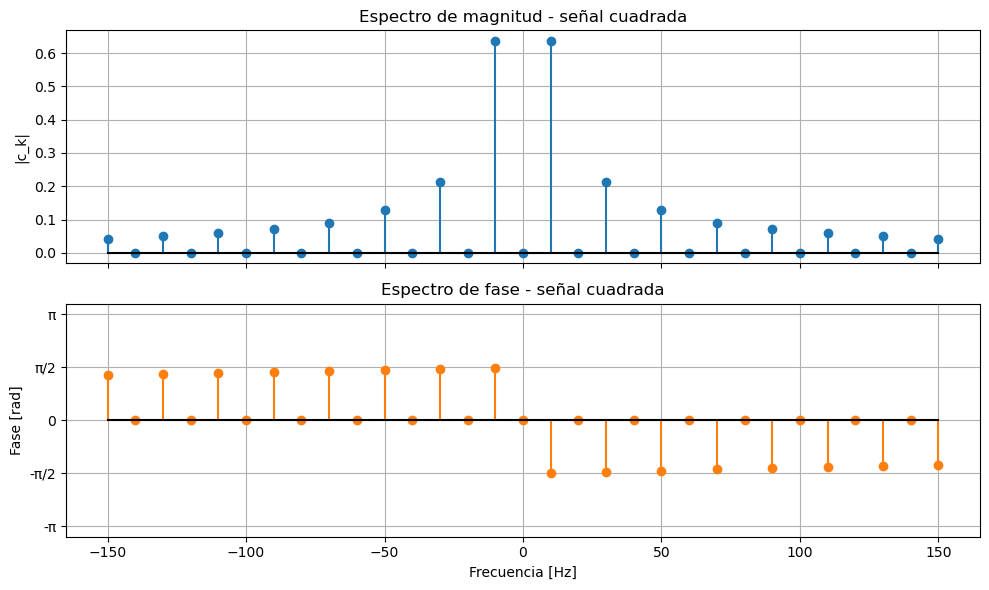

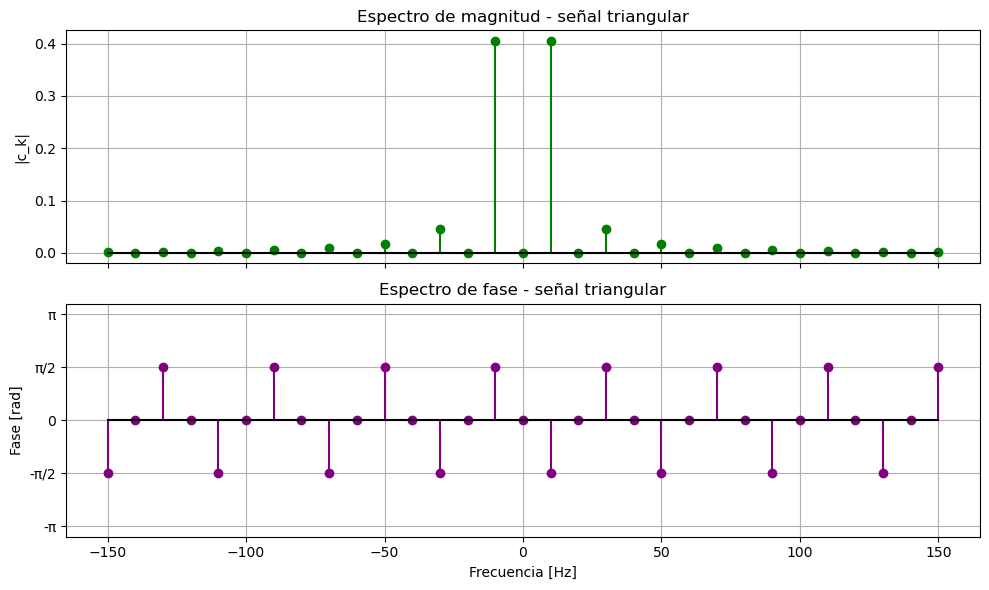

In [22]:
graficar_espectros(k_c, c_cuadrada, f0, "señal cuadrada",
                   color_mag="tab:blue", color_fase="tab:orange")
graficar_espectros(k_t, c_triangular, f0, "señal triangular",
                   color_mag="green", color_fase="purple")

plt.show()

h - Función que reconstruye una señal a partir de una suma de senos (armónicos), recibiendo 
como parámetros los coeficientes de Fourier y el número de armónicos a utilizar

i - Reconstrucción de la señal cuadrada y triangular, utilizando N = 1, 3, 5, 20 y 50 armónicos - Gráficas de cada reconstrucción junto con la señal original

j - Descripción del fenómeno de Gibbs observado en las reconstrucciones de la señal 
cuadrada

k - Carga de una señal ECG sin ruido y con su composición espectral 

 Descripción de los componentes de frecuencia principales asociados a las ondas P, al complejo QRS y a la onda T